# CKA Analysis for PAPNet and PCT

## Setup environment and download datasets

In [1]:
REPO_PATH = "/content/pointcloud-bench"

In [ ]:
!git clone --recursive --branch cka-similarity https://github.com/DavidClaszen/pointcloud-bench {REPO_PATH}


Cloning into '/content/pointcloud-bench'...
remote: Enumerating objects: 343, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 343 (delta 16), reused 21 (delta 16), pack-reused 305 (from 1)
Receiving objects: 100% (343/343), 39.66 MiB | 15.73 MiB/s, done.
Resolving deltas: 100% (145/145), done.
Submodule 'repos/PAPNet' (https://github.com/DavidClaszen/PAPNet.git) registered for path 'repos/PAPNet'
Submodule 'repos/Point-Transformers' (https://github.com/DavidClaszen/Point-Transformers.git) registered for path 'repos/Point-Transformers'
Cloning into '/content/pointcloud-bench/repos/PAPNet'...
remote: Enumerating objects: 133, done.        
remote: Counting objects: 100% (133/133), done.        
remote: Compressing objects: 100% (105/105), done.        
remote: Total 133 (delta 55), reused 85 (delta 27), pack-reused 0 (from 0)        
Receiving objects: 100% (133/133), 9.66 MiB | 15.75 MiB/s, done.
Resolving deltas: 100% (

In [ ]:
# For rolling changes, execute checkout to a select branch
%cd {REPO_PATH}
!git checkout cka-similarity
!git submodule update --init --recursive

/content/pointcloud-bench
Already on 'cka-similarity'
Your branch is up to date with 'origin/cka-similarity'.


In [ ]:
# Mount drive for pulling data and models
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [30]:
# Define the path to the dataset in Google Drive where the data and models are saved
# The folder must contain the following files:
# - partialmodelnet40.tar.gz
# - fullmodelnet40.tar.gz
# - PAPnet_final_models.tar.gz
drive_folder_path = '/content/drive/MyDrive/_Temp/cs7643-final-proj/'

# Check contents to make sure it's there
file_exists = lambda path: os.path.exists(path)
folder_exists = lambda path: os.path.isdir(path)
print("partialmodelnet40: ", "OK" if file_exists(os.path.join(drive_folder_path, 'partialmodelnet40.tar.gz')) else "NOT FOUND")
print("fullmodelnet40: ", "OK" if file_exists(os.path.join(drive_folder_path, 'fullmodelnet40.tar.gz')) else "NOT FOUND")
print("PAPnet models: ", "OK" if file_exists(os.path.join(drive_folder_path, 'PAPnet_final_models.tar.gz')) else "NOT FOUND")
print("PCT models: ", "OK" if file_exists(os.path.join(drive_folder_path, 'pct_final_models')) else "NOT FOUND")

partialmodelnet40:  OK
fullmodelnet40:  OK
PAPnet models:  OK
PCT models:  OK


In [ ]:
%cd {REPO_PATH}
%pip install -r envs/analysis/requirements.txt  --no-deps

/content/pointcloud-bench
  Cloning https://github.com/AMLab-Amsterdam/lie_learn (to revision master) to /tmp/pip-install-f3ah934q/lie-learn_ef032410441c476a8ae86a266adaf7b9
  Running command git clone --filter=blob:none --quiet https://github.com/AMLab-Amsterdam/lie_learn /tmp/pip-install-f3ah934q/lie-learn_ef032410441c476a8ae86a266adaf7b9
  Resolved https://github.com/AMLab-Amsterdam/lie_learn to commit edf012f5f60af320175d2e6269db78b984b5bfc3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.6/736.6 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [ ]:
# Copy select files from Google Drive to the repo dataset folder
!rsync -avP {drive_folder_path}/partialmodelnet40.tar.gz {REPO_PATH}/datasets
!rsync -avP {drive_folder_path}/fullmodelnet40.tar.gz {REPO_PATH}/datasets

sending incremental file list
partialmodelnet40.tar.gz
  2,162,130,396 100%   39.23MB/s    0:00:52 (xfr#1, to-chk=0/1)

sent 2,162,658,366 bytes  received 35 bytes  38,966,818.04 bytes/sec
total size is 2,162,130,396  speedup is 1.00
sending incremental file list
fullmodelnet40.tar.gz
  1,833,210,387 100%   72.85MB/s    0:00:23 (xfr#1, to-chk=0/1)

sent 1,833,658,058 bytes  received 35 bytes  69,194,645.02 bytes/sec
total size is 1,833,210,387  speedup is 1.00


In [ ]:
# Copy the models
!rsync -avP {drive_folder_path}/PAPnet_final_models.tar.gz {REPO_PATH}/repos/PAPNet/trained_models/
!rsync -avP {drive_folder_path}/pct_final_models/* {REPO_PATH}/checkpoints

sending incremental file list
created directory /content/pointcloud-bench/repos/PAPNet/trained_models
PAPnet_final_models.tar.gz
      7,766,652 100%   38.82MB/s    0:00:00 (xfr#1, to-chk=0/1)

sent 7,768,662 bytes  received 111 bytes  15,537,546.00 bytes/sec
total size is 7,766,652  speedup is 1.00
sending incremental file list
pct_p50.pth
     34,642,219 100%   28.73MB/s    0:00:01 (xfr#1, to-chk=4/5)
pct_p50_pct.pth
     34,642,524 100%   11.39MB/s    0:00:02 (xfr#2, to-chk=3/5)
pct_pct.pth
     34,642,219 100%   22.91MB/s    0:00:01 (xfr#3, to-chk=2/5)
pct_pct_p50.pth
     34,641,609 100%   12.59MB/s    0:00:02 (xfr#4, to-chk=1/5)
pct_pfull.pth
     34,642,219 100%   11.21MB/s    0:00:02 (xfr#5, to-chk=0/5)

sent 173,253,416 bytes  received 111 bytes  13,860,282.16 bytes/sec
total size is 173,210,790  speedup is 1.00


In [ ]:
# Extract zip files
%cd {REPO_PATH}
!tar -xvzf datasets/partialmodelnet40.tar.gz -C datasets
!tar -xvzf datasets/fullmodelnet40.tar.gz -C datasets
!tar -xvzf repos/PAPNet/trained_models/PAPnet_final_models.tar.gz -C repos/PAPNet/trained_models/

/content/pointcloud-bench
partialmodelnet40/
partialmodelnet40/test_labels.npy
partialmodelnet40/test_gt_tra.npy
partialmodelnet40/test_gt_rot.npy
partialmodelnet40/partialmodelnet40_shape_names.txt
partialmodelnet40/partialmodelnet40_test.txt
partialmodelnet40/partialmodelnet40_train.txt
partialmodelnet40/train_points.npy
partialmodelnet40/train_labels.npy
partialmodelnet40/train_gt_tra.npy
partialmodelnet40/train_gt_rot.npy
partialmodelnet40/test_points.npy
fullmodelnet40/
fullmodelnet40/test_filenames.txt
fullmodelnet40/test_gt_rot.npy
fullmodelnet40/test_gt_tra.npy
fullmodelnet40/test_labels.npy
fullmodelnet40/test_points.npy
fullmodelnet40/train_filenames.txt
fullmodelnet40/train_gt_rot.npy
fullmodelnet40/train_gt_tra.npy
fullmodelnet40/train_labels.npy
fullmodelnet40/train_points.npy
full_model.pth
partial_model.pth


# CKA Calculations

In [43]:
import sys
import gc
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from tqdm import tqdm
from typing import List

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sys.path.append(f"{REPO_PATH}/notebooks/")
sys.path.append(f"{REPO_PATH}/repos/PAPNet/")
sys.path.append(f"{REPO_PATH}/repos/Point-Transformers/")

from CKA import CKA, CudaCKA
from eval_models import eval_papnet
from dataloader import DataLoader as PAPNetDataset
from model import Model as PAPNetModel

## 1. Intra CKA for PAPNet

In [2]:
%cd {REPO_PATH}

/content/pointcloud-bench


In [64]:
def get_layer_repr_papnet(model: nn.Module,
                          layers: List[nn.Module],
                          dataloader: DataLoader,
                          device: torch.device,
                          max_batches: int = None):
    """
    Extract activations from specific layers for all data in dataloader.

    Args:
        model: PyTorch model
        layers: list of nn.Module, the layer(s) from which to extract features
        dataloader: DataLoader providing the data
        device: torch.device to run the model on
        max_batches: Optional[int], maximum number of batches to process

    Returns:
        features: np.ndarray of shape (N, D) where N is number of samples and D is feature dimension
        labels: np.ndarray of shape (N,) corresponding labels
    """
    model.eval()
    model.to(device)

    captured = {}
    handles = []

    def hook_fn(module, inp, out):
        # out: (B, D, ...) depending on layer
        captured[id(module)] = out.detach()

    for layer in layers:
        handles.append(layer.register_forward_hook(hook_fn))

    feats_list = [[] for _ in layers]
    labels_list = []

    with torch.no_grad():
        for b_idx, batch in enumerate(tqdm(dataloader, desc="Extracting features")):
            vol, gt_cls, gt_rot, gt_noi = batch
            vol = vol.to(device)

            _ = model(vol)               # forward; hook will populate captured[id(module)]

            # flatten the captured features
            for i, layer in enumerate(layers):
                feat = captured[id(layer)]  # (B, D, ...)
                feat = torch.flatten(feat, start_dim=1)  # (B, D)
                feats_list[i].append(feat.cpu())

            labels_list.append(gt_cls.cpu())

            if max_batches is not None and (b_idx + 1) >= max_batches:
                tqdm.write(f"Reached max_batches={max_batches}, stopping feature extraction.")
                break

    # Remove hooks
    for h in handles:
        h.remove()

    features = [torch.cat(feats, dim=0).numpy() for feats in feats_list]  # List of (N, D) arrays
    labels = torch.cat(labels_list, dim=0).numpy()   # (N,)
    return features, labels

def get_forward_order_papnet(model, dataset, device):
    """
    Get the order of module execution during a forward pass.

    Args:
        model: PyTorch model
        dataset: Dataset providing the data
        device: torch.device to run the model on
    Returns:
        execution_order: list of modules in the order they were executed.
    """
    execution_order = []

    # Get one sample to be used for determining the execution order
    sample_input = next(iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)))

    def hook_fn(module, input, output):
        execution_order.append(module)

    hooks = []
    for name, module in model.named_children():
        hooks.append(module.register_forward_hook(hook_fn))

    # Run a forward pass
    with torch.no_grad():
        vol, gt_cls, gt_rot, gt_noi = sample_input
        vol = vol.to(device)
        _ = model(vol)

    # Clean up hooks
    for h in hooks:
        h.remove()

    return execution_order

def compute_cka_matrix(features):
  # Compute CKA similarity matrix between all layers
  n_layers = len(features)
  cka_matrix = np.zeros((n_layers, n_layers))

  cuda_cka = CudaCKA(device)
  indices = np.triu_indices(len(features))
  print(f"Computing CKA for {n_layers} layers...")
  for ix in tqdm(range(len(indices[0])), desc="Calculating CKA"):
      i, j = indices[0][ix], indices[1][ix]
      # Convert to torch tensors and move to device
      X_i = torch.from_numpy(features[i]).to(device)
      X_j = torch.from_numpy(features[j]).to(device)

      # Compute linear CKA
      cka_score = cuda_cka.linear_CKA(X_i, X_j)
      cka_matrix[i, j] = cka_score
      cka_matrix[j, i] = cka_score  # Symmetric

      # Clean cache
      del X_i, X_j
      torch.cuda.empty_cache()
  return cka_matrix

def compute_cka_cross(features1: list, features2: list, device: torch.device) -> np.array:
    """
    Compute CKA similarity between two sets of features.

    Args:
        features1: list of np.ndarray, features from model 1
        features2: list of np.ndarray, features from model 2
        device: torch.device to run the computation on

    Returns:
        cka_scores: np.ndarray of shape (len(features1), len(features2)) with CKA similarity scores
    """
    cuda_cka = CudaCKA(device)

    cka_score = np.zeros((len(features1), len(features2)))
    print(f"Computing cross CKA for {len(features1)} x {len(features2)} layers...")

    row_idx, col_idx = np.indices((len(features1), len(features2)))

    for i, j in tqdm(zip(row_idx.flatten(), col_idx.flatten()), total=len(features1)*len(features2), desc="Cross CKA"):
        # Convert to torch tensors and move to device
        X_i = torch.from_numpy(features1[i]).to(device)
        X_j = torch.from_numpy(features2[j]).to(device)

        # Compute linear CKA
        cka_score[i, j] = cuda_cka.linear_CKA(X_i, X_j)

        # Clean cache
        del X_i, X_j
        torch.cuda.empty_cache()

    return cka_score

def print_samples_and_memory(features):
  print("Total number of activation samples:", features[0].shape[0])
  print("Number of activation samples per layer:")
  total_size_bytes = 0.0
  for i, feat in enumerate(features):
      size_bytes = feat.shape[0] * feat.shape[1] * feat.dtype.itemsize
      total_size_bytes += size_bytes
      print(f"Layer {i}: {feat.shape[0]} samples, {feat.shape[1]} features, total of {(size_bytes /  (1024**2)):.6f} MB")
  print(f"Total size of all activations: {(total_size_bytes /  (1024**2)):.2f} MB")

def viz_cka_matrix(cka_matrix, tick_interval=5, xylabel='Layers', title=''):
    fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
    ax = sns.heatmap(cka_matrix,
                cmap='magma', annot=False, ax=ax, vmin=0.0, vmax=1.0, cbar=False)
    ax.set_title(title, fontsize=20)
    ax.set_xlabel(xylabel, fontsize=18)
    ax.set_ylabel(xylabel, fontsize=18)
    ax.invert_yaxis()  # So that first layer is at the bottom
    return fig, ax


In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Load data
test_dataset_papnet = PAPNetDataset("pm40", root=f"{REPO_PATH}/datasets/fullmodelnet40", split='test')
test_dataloader_papnet = torch.utils.data.DataLoader(test_dataset_papnet, batch_size=32, shuffle=False,  pin_memory=True)

The size of test data is 2468


In [6]:
model_with_dataparallel = nn.DataParallel(PAPNetModel(num_class=40, num_k=1))
model_with_dataparallel.load_state_dict(torch.load(f"{REPO_PATH}/repos/PAPNet/trained_models/full_model.pth"), strict=False)
model_papnet = model_with_dataparallel.module.cuda()

model_papnet.eval()

layers_ord_papnet = get_forward_order_papnet(model_papnet, test_dataset_papnet, device)
print(f"Model has {len(layers_ord_papnet)} 1st-order network layer")

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5167: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/usr/local/lib/python3.12/dist-pac

Model has 37 1st-order network layer


In [10]:
for i, layer in enumerate(layers_ord_papnet):
  print(f"Layer {i}: {layer.__class__.__name__}")

Layer 0: GatedBlock
Layer 1: AvgPool3d
Layer 2: GatedBlock
Layer 3: GatedBlock
Layer 4: AvgPool3d
Layer 5: GatedBlock
Layer 6: GatedBlock
Layer 7: GatedBlock
Layer 8: GatedBlock
Layer 9: AvgPool3d
Layer 10: GatedBlock
Layer 11: GatedBlock
Layer 12: Upsample
Layer 13: GatedBlock
Layer 14: AvgPool3d
Layer 15: GatedBlock
Layer 16: GatedBlock
Layer 17: AvgSpacial
Layer 18: Linear
Layer 19: BatchNorm1d
Layer 20: ReLU
Layer 21: Linear
Layer 22: BatchNorm1d
Layer 23: ReLU
Layer 24: Linear
Layer 25: GatedBlock
Layer 26: AvgPool3d
Layer 27: GatedBlock
Layer 28: GatedBlock
Layer 29: AvgSpacial
Layer 30: Linear
Layer 31: BatchNorm1d
Layer 32: ReLU
Layer 33: Linear
Layer 34: BatchNorm1d
Layer 35: ReLU
Layer 36: Linear


In [11]:
features_papnet, labels_papnet = get_layer_repr_papnet(
    model=model_papnet,
    layers=layers_ord_papnet,
    dataloader=test_dataloader_papnet,
    device=device,
    max_batches=10  # limit to 10 batches for speed
)

Extracting features:   0%|          | 0/78 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5167: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for d

Reached max_batches=10, stopping feature extraction.


In [12]:
print_samples_and_memory(features_papnet)

Total number of activation samples: 320
Number of activation samples per layer:
Layer 0: 320 samples, 8388608 features, total of 10240.000000 MB
Layer 1: 320 samples, 131072 features, total of 160.000000 MB
Layer 2: 320 samples, 2097152 features, total of 2560.000000 MB
Layer 3: 320 samples, 2097152 features, total of 2560.000000 MB
Layer 4: 320 samples, 131072 features, total of 160.000000 MB
Layer 5: 320 samples, 262144 features, total of 320.000000 MB
Layer 6: 320 samples, 262144 features, total of 320.000000 MB
Layer 7: 320 samples, 524288 features, total of 640.000000 MB
Layer 8: 320 samples, 524288 features, total of 640.000000 MB
Layer 9: 320 samples, 131072 features, total of 160.000000 MB
Layer 10: 320 samples, 131072 features, total of 160.000000 MB
Layer 11: 320 samples, 131072 features, total of 160.000000 MB
Layer 12: 320 samples, 1048576 features, total of 1280.000000 MB
Layer 13: 320 samples, 1048576 features, total of 1280.000000 MB
Layer 14: 320 samples, 131072 feature

In [13]:
cka_matrix_papnet = compute_cka_matrix(features_papnet)
print("CKA similarity calculation complete.")

Computing CKA for 37 layers...


Calculating CKA: 100%|██████████| 703/703 [04:51<00:00,  2.41it/s]

CKA similarity calculation complete.


In [76]:
np.save(os.path.join(drive_folder_path, "results", "cka_matrix_papnet.npy"), cka_matrix_papnet)
np.savetxt(os.path.join(drive_folder_path, "results", "cka_matrix_papnet.csv"), cka_matrix_papnet, delimiter=",")

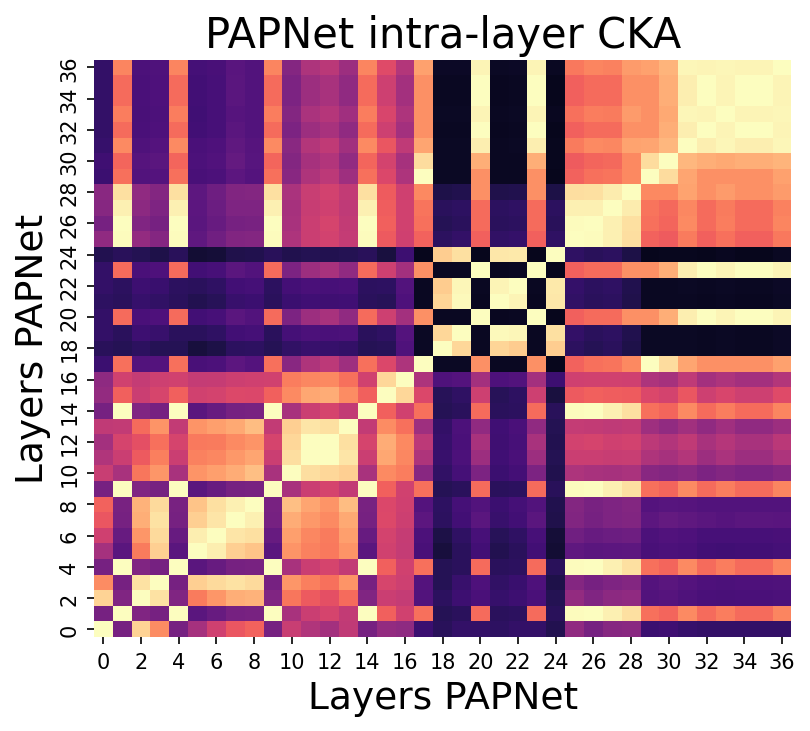

In [60]:
# Now visualize the CKA matrix using seaborn heatmap
fig, ax = viz_cka_matrix(cka_matrix=cka_matrix_papnet,
                         tick_interval=5,
                         xylabel='Layers PAPNet', title='PAPNet intra-layer CKA')
# save graph
fig.savefig(os.path.join(drive_folder_path, "results", "cka_papnet.svg"), bbox_inches='tight')

## 2. Intra CKA for PAPNet

In [19]:
import os
import hydra
import importlib
from hydra import initialize_config_dir, compose
from test_cls import get_predictions
from omegaconf import OmegaConf
from dataset import PAPNetDataLoader as PCTDataset

# Train PCT, test PAPNet
torch.serialization.add_safe_globals([
    np.core.multiarray.scalar,  # For NumPy scalars
    np.dtype,                   # For NumPy data types
    np.dtype('float64').__class__, # For the specific float64 dtype class
])

config_dir = os.path.join(REPO_PATH, 'repos', 'Point-Transformers', 'config')

with initialize_config_dir(config_dir=config_dir, version_base="1.2"):
    cfg = compose(
        config_name="cls",
        overrides=[
            "data_path=../../datasets/fullmodelnet40/",
            "checkpoint_path=../../checkpoints/pct_pfull.pth",
            "use_papnet_loader=true"
        ],
    )

OmegaConf.set_struct(cfg, False)

In [20]:
%cd {REPO_PATH}/repos/Point-Transformers

/content/pointcloud-bench/repos/Point-Transformers


In [21]:
# Load data
args = cfg
test_dataset_pct = PCTDataset(
    root=hydra.utils.to_absolute_path(args.data_path),
    npoint=args.num_point,
    split='test',
    normal_channel=args.normal,
)

test_loader_pct = torch.utils.data.DataLoader(
    test_dataset_pct,
    batch_size=32,
    shuffle=False,
    num_workers=args.workers,
)

# ---- MODEL LOADING ----
args.num_class = 40
args.input_dim = 6 if args.normal else 3

ModelCls = getattr(
    importlib.import_module(f"models.{args.model.name}.model"),
    "PointTransformerCls",
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pct = ModelCls(args).to(device)
checkpoint = torch.load(args.checkpoint_path, map_location=device)
model_pct.load_state_dict(checkpoint["model_state_dict"])
print(f"Model loaded with {checkpoint['epoch']} epochs")
model_pct.eval()

The size of test data is 2468
Model loaded with 34 epochs


PointTransformerCls(
  (conv1): Conv1d(6, 64, kernel_size=(1,), stride=(1,), bias=False)
  (conv2): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gather_local_0): Local_op(
    (conv1): Conv1d(128, 128, kernel_size=(1,), stride=(1,), bias=False)
    (conv2): Conv1d(128, 128, kernel_size=(1,), stride=(1,), bias=False)
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (gather_local_1): Local_op(
    (conv1): Conv1d(256, 256, kernel_size=(1,), stride=(1,), bias=False)
    (conv2): Conv1d(256, 256, kernel_size=(1,), stride=(1,), bias=False)
    (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): Ba

In [22]:
from models.Menghao.model import Local_op, StackedAttention

def get_layer_repr_pct(model: nn.Module,
                       layers: List[nn.Module],
                       dataloader: DataLoader,
                       device: torch.device,
                       max_batches: int = None):
    """
    Extract activations from specific layers for all data in dataloader.

    Args:
        model: PyTorch model
        layers: list of nn.Module, the layer(s) from which to extract features
        dataloader: DataLoader providing the data
        device: torch.device to run the model on
        max_batches: Optional[int], maximum number of batches to process

    Returns:
        features: np.ndarray of shape (N, D) where N is number of samples and D is feature dimension
        labels: np.ndarray of shape (N,) corresponding labels
    """
    model.eval()
    model.to(device)

    captured = {}
    handles = []

    def hook_fn(module, inp, out):
        # out: (B, D, ...) depending on layer
        captured[id(module)] = out.detach()

    for layer in layers:
        handles.append(layer.register_forward_hook(hook_fn))

    feats_list = [[] for _ in layers]
    labels_list = []

    with torch.no_grad():
        for b_idx, batch in enumerate(tqdm(dataloader, desc="Extracting features")):
            points, target = batch
            target = target[:, 0]
            points = points.to(device)
            _ = model(points)               # forward; hook will populate captured[id(module)]

            # flatten the captured features
            for i, layer in enumerate(layers):
                feat = captured[id(layer)]  # (B, D, ...)
                feat = torch.flatten(feat, start_dim=1)  # (B, D)
                feats_list[i].append(feat.cpu())

            labels_list.append(target.cpu())

            if max_batches is not None and (b_idx + 1) >= max_batches:
                tqdm.write(f"Reached max_batches={max_batches}, stopping feature extraction.")
                break

    # Remove hooks
    for h in handles:
        h.remove()

    features = [torch.cat(feats, dim=0).numpy() for feats in feats_list]  # List of (N, D) arrays
    labels = torch.cat(labels_list, dim=0).numpy()   # (N,)
    return features, labels

def get_forward_order_pct(model, dataset, device):
    """
    Get the order of module execution during a forward pass.

    Args:
        model: PyTorch model
        dataset: Dataset providing the data
        device: torch.device to run the model on
    Returns:
        execution_order: list of modules in the order they were executed.
    """
    execution_order = []

    # Get one sample to be used for determining the execution order
    sample_input = next(iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)))

    def hook_fn(module, input, output):
        execution_order.append(module)

    hooks = []
    for name, module in model.named_children():
      if isinstance(module, (StackedAttention)):
        # get 2nd level
        for name_child, module_child in module.named_children():
          hooks.append(module_child.register_forward_hook(hook_fn))
      else:
        hooks.append(module.register_forward_hook(hook_fn))

    # Run a forward pass
    with torch.no_grad():
        points, target = sample_input
        points = points.to(device)
        _ = model(points)

    # Clean up hooks
    for h in hooks:
        h.remove()

    return execution_order

In [23]:
layers_ord_pct = get_forward_order_pct(model_pct, test_dataset_pct, device)
print(f"Model has {len(layers_ord_pct)} 1st-order network layer")

Model has 28 1st-order network layer


In [78]:
for i, layer in enumerate(layers_ord_pct):
  print(f"Layer {i}: {layer.__class__.__name__}")

Layer 0: Conv1d
Layer 1: BatchNorm1d
Layer 2: ReLU
Layer 3: Conv1d
Layer 4: BatchNorm1d
Layer 5: ReLU
Layer 6: Local_op
Layer 7: Local_op
Layer 8: Conv1d
Layer 9: BatchNorm1d
Layer 10: ReLU
Layer 11: Conv1d
Layer 12: BatchNorm1d
Layer 13: ReLU
Layer 14: SA_Layer
Layer 15: SA_Layer
Layer 16: SA_Layer
Layer 17: SA_Layer
Layer 18: Sequential
Layer 19: Linear
Layer 20: BatchNorm1d
Layer 21: ReLU
Layer 22: Dropout
Layer 23: Linear
Layer 24: BatchNorm1d
Layer 25: ReLU
Layer 26: Dropout
Layer 27: Linear


In [25]:
features_pct, labels_pct = get_layer_repr_pct(
    model=model_pct,
    layers=layers_ord_pct,
    dataloader=test_loader_pct,
    device=device,
    max_batches=10  # limit to 10 batches for memory
)

Extracting features:  12%|█▏        | 9/78 [00:03<00:18,  3.67it/s]

Reached max_batches=10, stopping feature extraction.


Extracting features:  12%|█▏        | 9/78 [00:03<00:26,  2.59it/s]


In [26]:
print_samples_and_memory(features_pct)

Total number of activation samples: 320
Number of activation samples per layer:
Layer 0: 320 samples, 65536 features, total of 80.000000 MB
Layer 1: 320 samples, 65536 features, total of 80.000000 MB
Layer 2: 320 samples, 256 features, total of 0.312500 MB
Layer 3: 320 samples, 65536 features, total of 80.000000 MB
Layer 4: 320 samples, 65536 features, total of 80.000000 MB
Layer 5: 320 samples, 256 features, total of 0.312500 MB
Layer 6: 320 samples, 65536 features, total of 80.000000 MB
Layer 7: 320 samples, 65536 features, total of 80.000000 MB
Layer 8: 320 samples, 65536 features, total of 80.000000 MB
Layer 9: 320 samples, 65536 features, total of 80.000000 MB
Layer 10: 320 samples, 65536 features, total of 80.000000 MB
Layer 11: 320 samples, 65536 features, total of 80.000000 MB
Layer 12: 320 samples, 65536 features, total of 80.000000 MB
Layer 13: 320 samples, 65536 features, total of 80.000000 MB
Layer 14: 320 samples, 65536 features, total of 80.000000 MB
Layer 15: 320 samples

In [27]:
cka_matrix_pct = compute_cka_matrix(features_pct)

Computing CKA for 28 layers...


Calculating CKA: 100%|██████████| 406/406 [00:14<00:00, 28.24it/s]


In [77]:
np.save(os.path.join(drive_folder_path, "results", "cka_matrix_pct.npy"), cka_matrix_pct)
np.savetxt(os.path.join(drive_folder_path, "results", "cka_matrix_pct.csv"), cka_matrix_pct, delimiter=",")

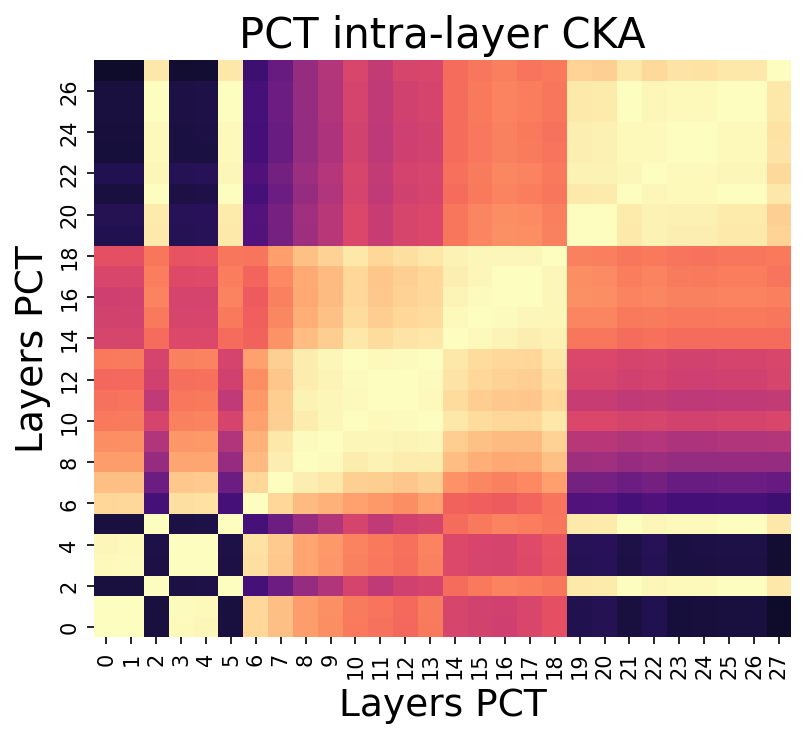

In [62]:
fig, ax = viz_cka_matrix(cka_matrix_pct,
                         tick_interval=5,
                         xylabel='Layers PCT', title='PCT intra-layer CKA')
# save graph
fig.savefig(os.path.join(drive_folder_path, "results", "cka_pct.svg"), bbox_inches='tight')

## Cross-model CKA

In [ ]:
cka_matrix_cross = compute_cka_cross(features_papnet, features_pct, device)

In [75]:
np.save(os.path.join(drive_folder_path, "results", "cka_cross.npy"), cka_matrix_cross)
np.savetxt(os.path.join(drive_folder_path, "results", "cka_cross.csv"), cka_matrix_cross, delimiter=",")

In [ ]:
cka_matrix_cross.shape

(37, 19)

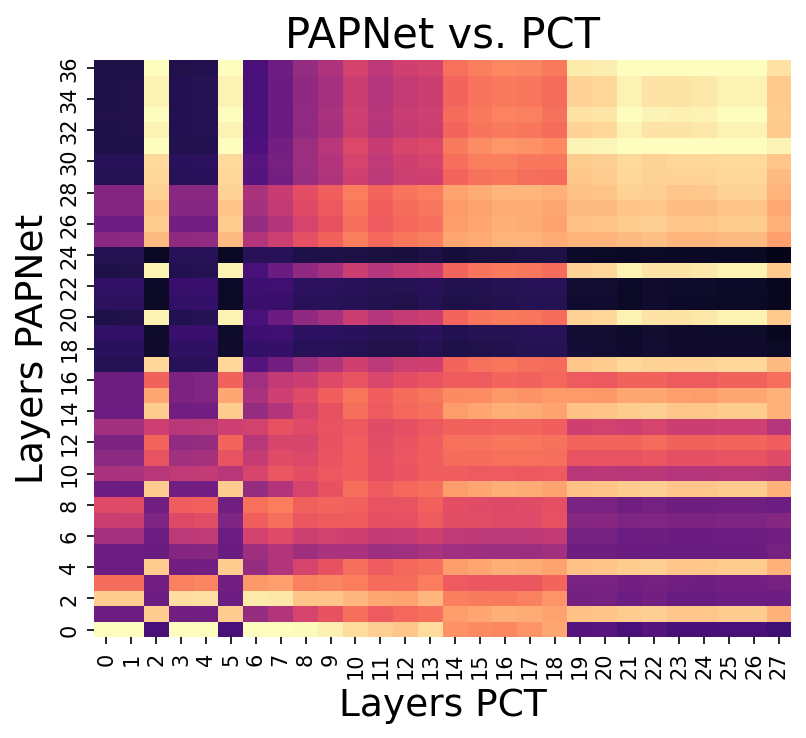

In [70]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
ax = sns.heatmap(cka_matrix_cross,
            cmap='magma', annot=False, ax=ax, vmin=0.0, vmax=0.85, cbar=False)
ax.set_title('PAPNet vs. PCT', fontsize=20)
ax.set_xlabel('Layers PCT', fontsize=18)
ax.set_ylabel('Layers PAPNet', fontsize=18)
ax.invert_yaxis()  # So that first layer is at the bottom
fig.savefig(os.path.join(drive_folder_path, "results", "cka_cross.svg"), bbox_inches='tight')